1.0 1.0
[[10  0]
 [ 0 14]]


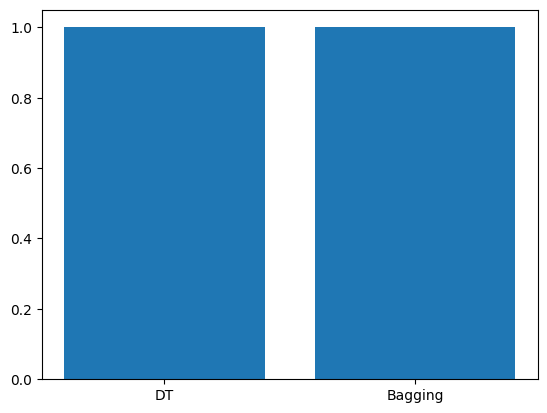

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("diabetes_bagging.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
acc_bag = accuracy_score(y_test, y_pred_bag)

print(acc_dt, acc_bag)
print(confusion_matrix(y_test, y_pred_bag))

plt.bar(["DT","Bagging"], [acc_dt, acc_bag])
plt.show()

AdaBoost Accuracy: 0.9375
Gradient Boosting Accuracy: 0.9375


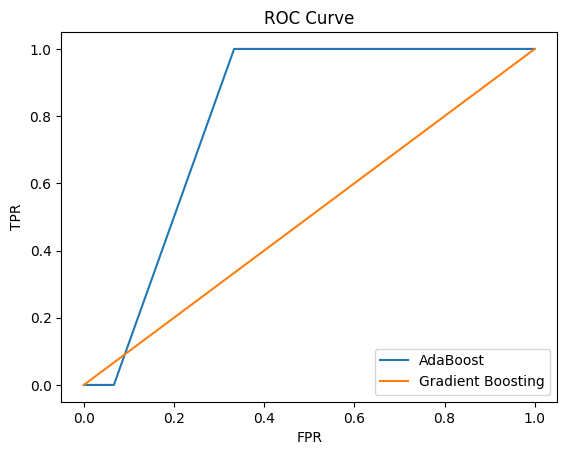

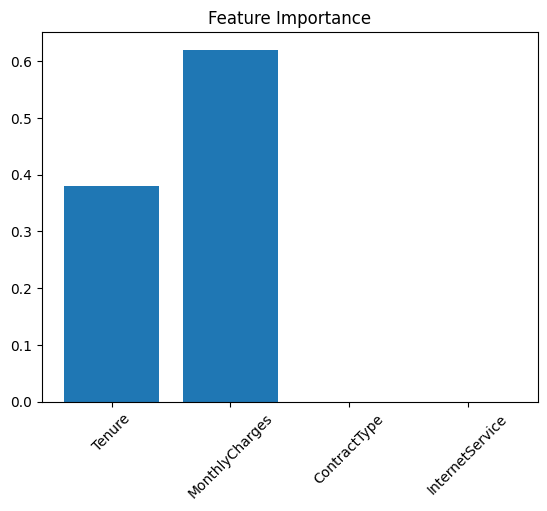

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve

df = pd.read_csv("churn_boosting.csv")

df = df.dropna()

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

target_col = [col for col in df.columns if "churn" in col.lower()][0]

X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_prob_ada = ada.predict_proba(X_test)[:, 1]
y_pred_ada = ada.predict(X_test)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_prob_gb = gb.predict_proba(X_test)[:, 1]
y_pred_gb = gb.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label="AdaBoost")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

plt.figure()
plt.bar(X.columns, gb.feature_importances_)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()


Unique Income values: [0 1]
Remaining rows: 120


/tmp/ipykernel_41676/2945596132.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Income"] = df["Income"].replace({


Accuracy: [1.0, 1.0, 1.0]


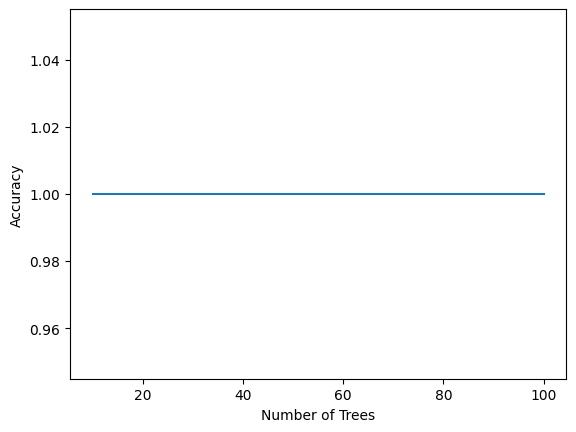

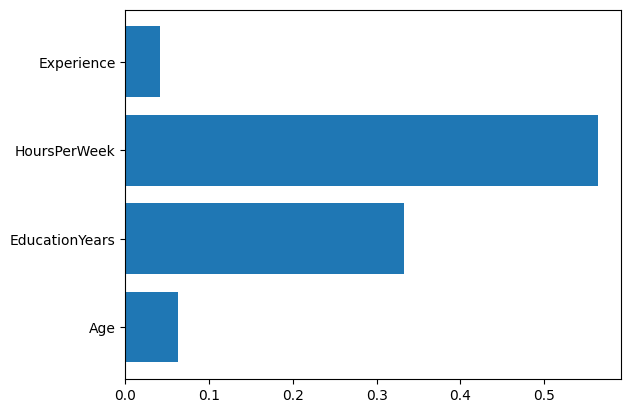

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("income_random_forest.csv")

print("Unique Income values:", df["Income"].unique())

df["Income"] = df["Income"].astype(str).str.strip().str.lower()

df["Income"] = df["Income"].replace({
    ">50k":1, "<=50k":0,
    "high":1, "low":0,
    "yes":1, "no":0,
    "1":1, "0":0
})

df = df[df["Income"].isin([0,1])]

print("Remaining rows:", len(df))

if len(df) == 0:
    raise ValueError("Dataset became empty. Check Income values.")

X = df.drop("Income", axis=1)
y = df["Income"]

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

trees = [10, 50, 100]
acc = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))

print("Accuracy:", acc)

plt.plot(trees, acc)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.barh(X.columns, rf.feature_importances_)
plt.show()

LR: 0.9166666666666666
SVM: 0.9583333333333334
DT: 1.0
Stack: 1.0


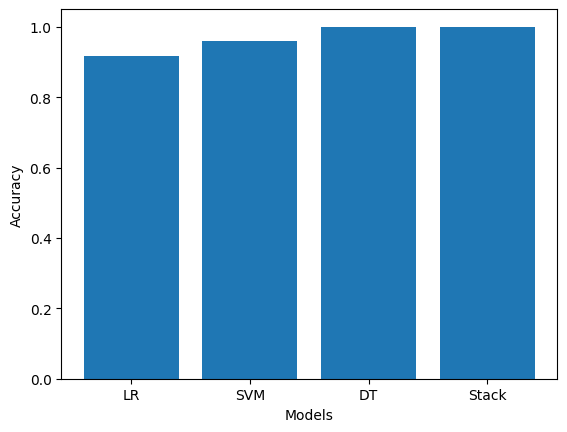

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("heart_stacking.csv")

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

stack = StackingClassifier(
    estimators=[('lr', lr), ('svm', svm), ('dt', dt)],
    final_estimator=LogisticRegression()
)

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)
stack.fit(X_train, y_train)

acc_lr = accuracy_score(y_test, lr.predict(X_test))
acc_svm = accuracy_score(y_test, svm.predict(X_test))
acc_dt = accuracy_score(y_test, dt.predict(X_test))
acc_stack = accuracy_score(y_test, stack.predict(X_test))

print("LR:", acc_lr)
print("SVM:", acc_svm)
print("DT:", acc_dt)
print("Stack:", acc_stack)

plt.bar(["LR","SVM","DT","Stack"], [acc_lr, acc_svm, acc_dt, acc_stack])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

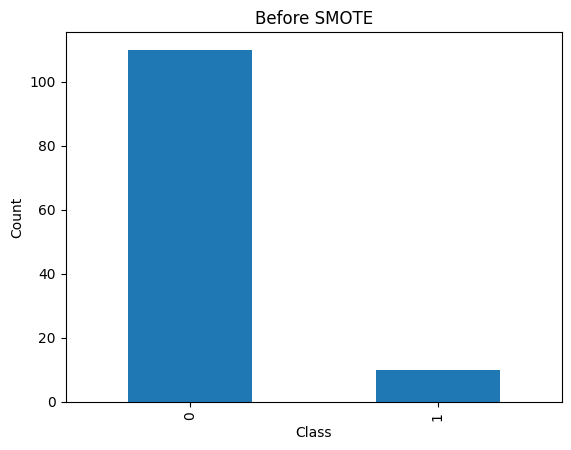

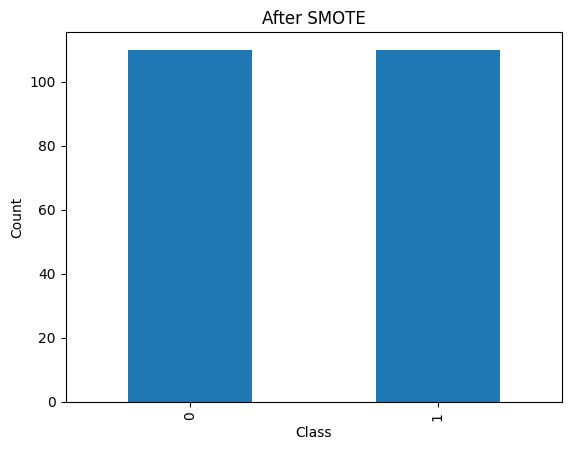

Accuracy: 0.8181818181818182
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        20
           1       0.81      0.88      0.84        24

    accuracy                           0.82        44
   macro avg       0.82      0.81      0.81        44
weighted avg       0.82      0.82      0.82        44



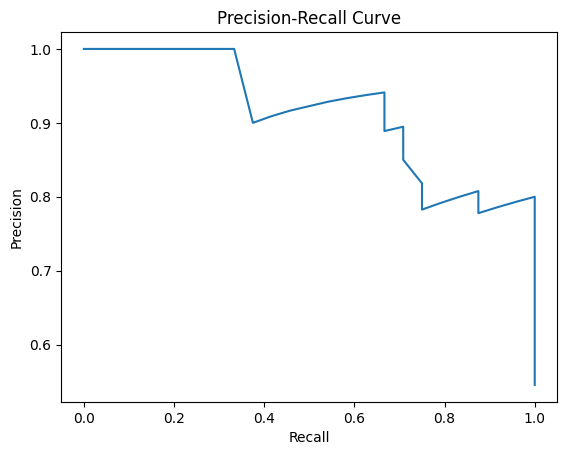

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve

df = pd.read_csv("fraud_smote.csv")

X = df.drop("Fraud", axis=1)
y = df["Fraud"]

plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

sm = SMOTE()
X_res, y_res = sm.fit_resample(X, y)

plt.figure()
pd.Series(y_res).value_counts().plot(kind='bar')
plt.title("After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()